# 📊 Dataset Exploration - AI LogGuard Phase 3

**Mục đích:** Phân tích và khám phá synthetic CI/CD log dataset

**Nội dung:**
- Load dataset từ GitHub
- Visualize phân phối error categories và platforms
- Phân tích mẫu logs
- Tạo train/val/test splits

## 1. Setup & Installation

In [12]:
# Install required packages
!pip install pandas matplotlib seaborn scikit-learn -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from sklearn.model_selection import train_test_split

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Clone Repository & Load Dataset

In [ ]:
# Clone repository và thiết lập đường dẫn
import os
from pathlib import Path

# Xác định đường dẫn tuyệt đối
notebook_dir = Path.cwd()
repo_dir = notebook_dir / "AI-LogGuard"

print(f"📂 Notebook directory: {notebook_dir}")
print(f"📂 Repository target: {repo_dir}")

# Xóa repo cũ nếu tồn tại
if repo_dir.exists():
    import shutil
    print(f"🗑️  Removing existing repo at {repo_dir}")
    shutil.rmtree(repo_dir)

# Clone repository mới
print("📥 Cloning repository...")
!git clone https://github.com/SyLe-Van/AI-LogGuard.git

# Verify structure
if repo_dir.exists():
    print(f"✅ Repository cloned successfully!")
    print(f"📁 Contents: {list(repo_dir.iterdir())[:5]}")
else:
    print("❌ Clone failed!")

In [ ]:
# Load dataset với đường dẫn tuyệt đối
repo_dir = Path.cwd() / "AI-LogGuard"
dataset_path = repo_dir / "data" / "synthetic_logs" / "dataset.csv"

print(f"📂 Loading dataset from: {dataset_path}")
print(f"✓ File exists: {dataset_path.exists()}")

df = pd.read_csv(dataset_path)

# Cập nhật file_path thành absolute paths
df['file_path'] = df['file_path'].apply(lambda x: str(repo_dir / x))

print(f"\n📊 Total logs: {len(df)}")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n🔍 First 5 rows:")
df.head()

In [ ]:
# Load statistics
stats_path = repo_dir / "data" / "synthetic_logs" / "statistics.json"

with open(stats_path) as f:
    stats = json.load(f)

print(json.dumps(stats, indent=2))

## 3. Data Analysis

In [26]:
# Basic statistics
print("📊 Dataset Info:")
print(df.info())

print("\n📈 Value counts:")
print("\nError Categories:")
print(df['error_category'].value_counts())

print("\nPlatforms:")
print(df['platform'].value_counts())

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   log_id          300 non-null    object
 1   file_path       300 non-null    object
 2   platform        300 non-null    object
 3   error_category  300 non-null    object
 4   build_number    300 non-null    int64 
 5   timestamp       300 non-null    object
dtypes: int64(1), object(5)
memory usage: 14.2+ KB
None

📈 Value counts:

Error Categories:
error_category
dependency_error     75
test_failure         60
syntax_error         60
timeout              45
environment_error    30
network_error        15
permission_error     15
Name: count, dtype: int64

Platforms:
platform
github-actions    103
gitlab-ci          99
jenkins            98
Name: count, dtype: int64


## 4. Visualizations

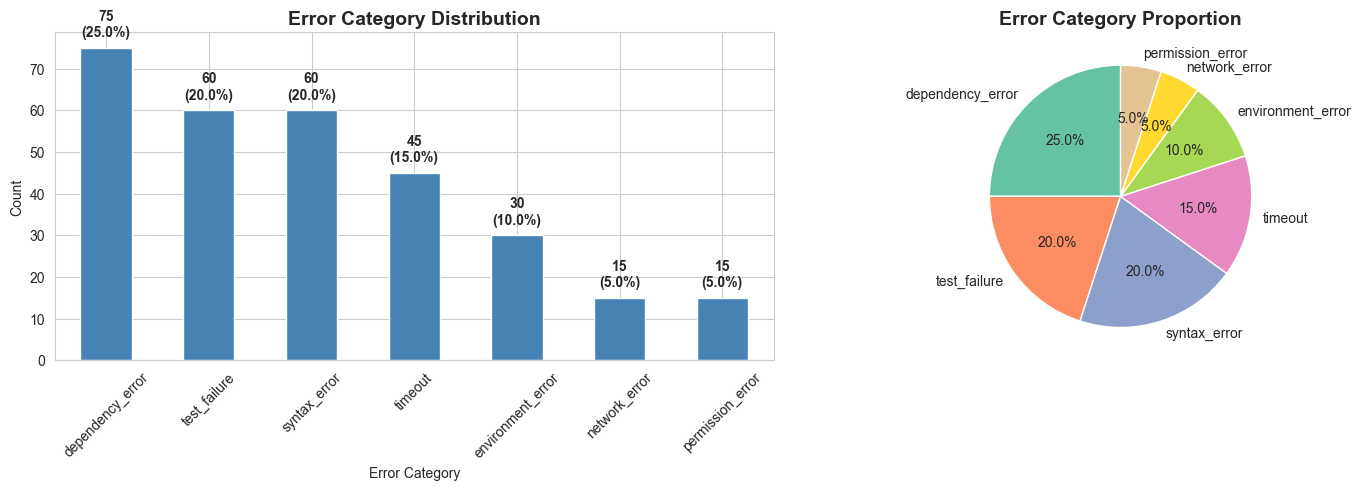


⚖️  Balance ratio: 0.20
❌ Imbalanced - MUST use class_weight='balanced' when training


In [27]:
# Error category distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
error_counts = df['error_category'].value_counts()
error_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Error Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Error Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Add percentages on bars
for i, v in enumerate(error_counts):
    axes[0].text(i, v + 2, f'{v}\n({v/len(df)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(error_counts, labels=error_counts.index, autopct='%1.1f%%', 
           startangle=90, colors=sns.color_palette('Set2'))
axes[1].set_title('Error Category Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check balance
balance_ratio = error_counts.min() / error_counts.max()
print(f"\n⚖️  Balance ratio: {balance_ratio:.2f}")
if balance_ratio >= 0.7:
    print("✅ Well balanced!")
elif balance_ratio >= 0.5:
    print("⚠️  Moderately balanced - consider using class_weight='balanced'")
else:
    print("❌ Imbalanced - MUST use class_weight='balanced' when training")

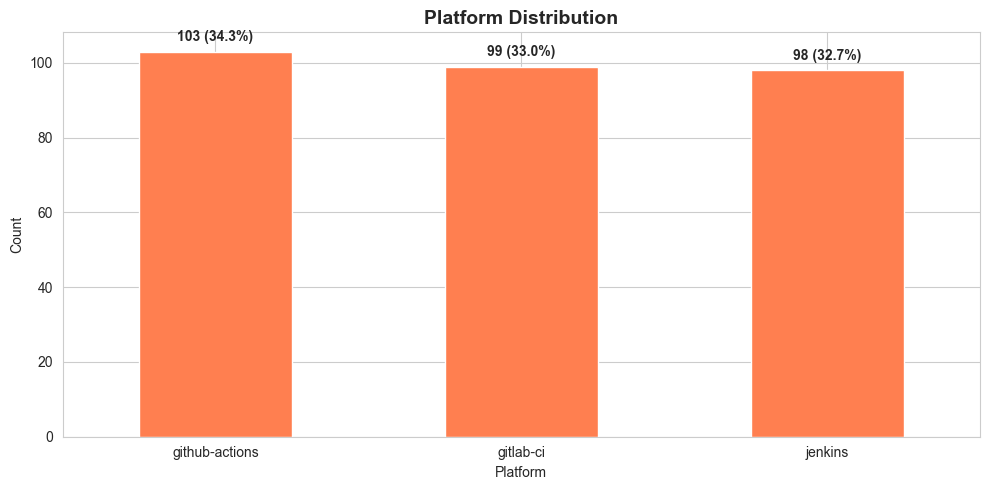

In [28]:
# Platform distribution
fig, ax = plt.subplots(figsize=(10, 5))

platform_counts = df['platform'].value_counts()
platform_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Platform Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Platform')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# Add percentages
for i, v in enumerate(platform_counts):
    ax.text(i, v + 2, f'{v} ({v/len(df)*100:.1f}%)', 
           ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

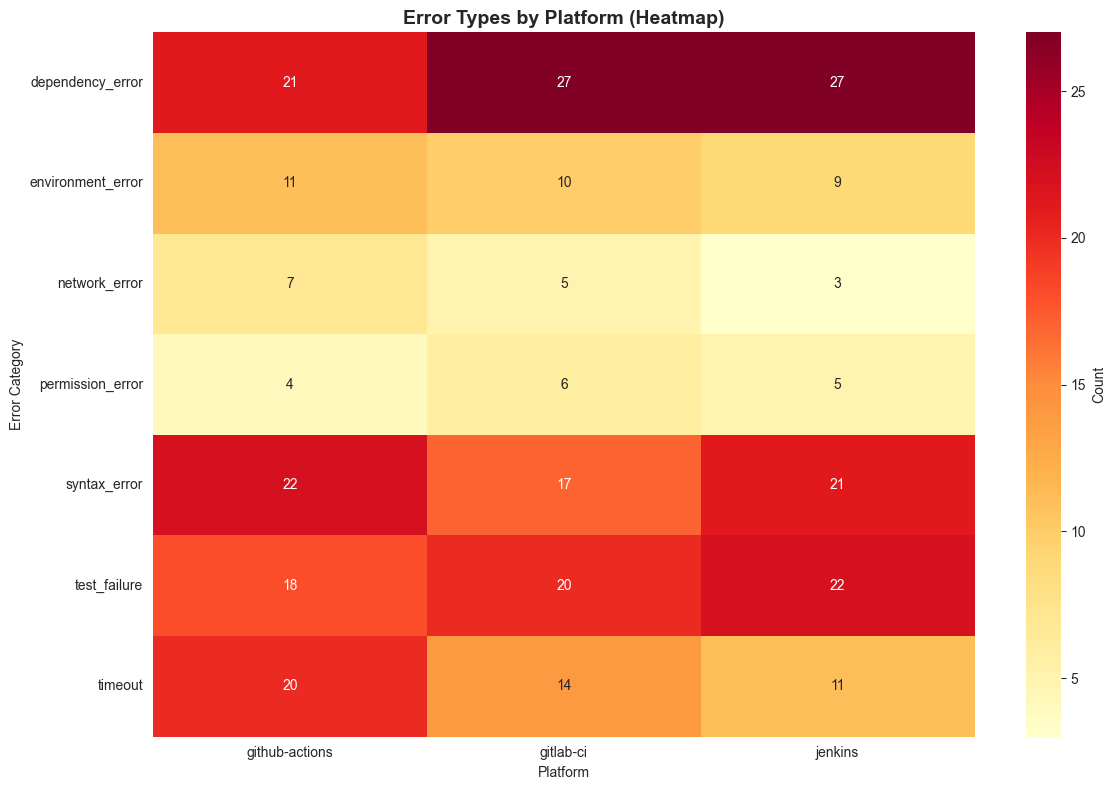


📊 Cross-tabulation:
platform           github-actions  gitlab-ci  jenkins
error_category                                       
dependency_error               21         27       27
environment_error              11         10        9
network_error                   7          5        3
permission_error                4          6        5
syntax_error                   22         17       21
test_failure                   18         20       22
timeout                        20         14       11


In [29]:
# Cross-tabulation: Error types by Platform
cross_tab = pd.crosstab(df['error_category'], df['platform'])

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Error Types by Platform (Heatmap)', fontsize=14, fontweight='bold')
ax.set_xlabel('Platform')
ax.set_ylabel('Error Category')
plt.tight_layout()
plt.show()

print("\n📊 Cross-tabulation:")
print(cross_tab)

## 5. Sample Log Analysis

In [ ]:
# Read and display sample logs from each category
def display_sample_log(category, max_lines=30):
    """Display a sample log from a specific error category"""
    sample = df[df['error_category'] == category].iloc[0]
    
    print("=" * 80)
    print(f"📝 Category: {category}")
    print(f"🔧 Platform: {sample['platform']}")
    print(f"📄 File: {sample['file_path']}")
    print("=" * 80)
    
    # Read log file với absolute path
    log_path = Path(sample['file_path'])
    
    # Verify file exists
    if not log_path.exists():
        print(f"❌ File not found: {log_path}")
        print(f"   Current working dir: {Path.cwd()}")
        return
    
    with open(log_path) as f:
        content = f.read()
    
    lines = content.split('\n')
    print(f"\nTotal lines: {len(lines)}")
    print(f"\nFirst {max_lines} lines:")
    print("-" * 80)
    for i, line in enumerate(lines[:max_lines], 1):
        print(f"{i:3d} | {line}")
    
    if len(lines) > max_lines:
        print(f"\n... ({len(lines) - max_lines} more lines)")
    print("\n")

# Display one sample from each category
for category in df['error_category'].unique():
    display_sample_log(category, max_lines=25)

## 6. Create Train/Val/Test Splits

In [ ]:
# Stratified split để giữ tỉ lệ error categories
# 70% train, 15% val, 15% test

# First split: 70% train, 30% temp (val+test)
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3, 
    stratify=df['error_category'],
    random_state=42
)

# Second split: 50% val, 50% test (of the 30%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['error_category'],
    random_state=42
)

print("📊 Dataset Splits:")
print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

print("\n✅ Distribution in each split:")
print("\nTrain:")
print(train_df['error_category'].value_counts().sort_index())
print("\nVal:")
print(val_df['error_category'].value_counts().sort_index())
print("\nTest:")
print(test_df['error_category'].value_counts().sort_index())

In [ ]:
# Save splits
output_dir = repo_dir / "data" / "synthetic_logs"

train_df.to_csv(output_dir / "train.csv", index=False)
val_df.to_csv(output_dir / "val.csv", index=False)
test_df.to_csv(output_dir / "test.csv", index=False)

print("💾 Splits saved:")
print(f"  - {output_dir / 'train.csv'}")
print(f"  - {output_dir / 'val.csv'}")
print(f"  - {output_dir / 'test.csv'}")

## 7. Summary Statistics

In [ ]:
# Read a few log files to analyze text characteristics
log_lengths = []
for file_path in df['file_path'].head(50):  # Sample 50 logs
    try:
        log_path = Path(file_path)
        if log_path.exists():
            with open(log_path) as f:
                content = f.read()
                log_lengths.append(len(content))
    except Exception as e:
        print(f"⚠️  Error reading {file_path}: {e}")

if log_lengths:
    print("📏 Log File Statistics (sample of 50):")
    print(f"Average length: {np.mean(log_lengths):.0f} characters")
    print(f"Min length: {np.min(log_lengths)} characters")
    print(f"Max length: {np.max(log_lengths)} characters")
    print(f"Median length: {np.median(log_lengths):.0f} characters")

    # Visualize log length distribution
    plt.figure(figsize=(10, 5))
    plt.hist(log_lengths, bins=20, color='skyblue', edgecolor='black')
    plt.xlabel('Log Length (characters)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Log File Lengths', fontsize=14, fontweight='bold')
    plt.axvline(np.mean(log_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(log_lengths):.0f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("❌ No log files found to analyze")

## ✅ Kết Luận

Dataset đã được phân tích và chia thành 3 tập:
- ✅ Train/Val/Test splits created
- ✅ Stratified splitting maintains class distribution
- ✅ Ready for feature engineering (Notebook 02)

**Next Steps:**
1. ➡️ Notebook 02: Feature Engineering (TF-IDF, structural features)
2. ➡️ Notebook 03: Model Training (Logistic Regression, Random Forest)
3. ➡️ Notebook 04: Model Evaluation
4. ➡️ Notebook 05: Export for CLI Integration